# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**============================================================================**

Pada proyek ini, dataset yang digunakan adalah Stroke Prediction Dataset dari Kaggle.

source : https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Tujuan Project ini adalah membangun model machine learning yang dapat memprediksi probabilitas seorang pasien mengalami stroke berdasarkan parameter input seperti usia, kondisi kesehatan, dan gaya hidup.

Ini adalah masalah klasifikasi biner, di mana targetnya adalah:

*   0 : Tidak stroke
*   1 : Stroke


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [18]:
# Instalasi library kagglehub
!pip install kagglehub --quiet

In [19]:
# Library utama
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# Library Preprocessing dari Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Mengatur agar plot Seaborn tampil dengan style yang rapi
sns.set_theme(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [20]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [21]:
print(os.listdir("/kaggle/input/stroke-prediction-dataset"))

['healthcare-dataset-stroke-data.csv']


In [22]:
df = pd.read_csv("/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

**Informasi Umum Dataset**

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**Statistik Deskriptif**

In [24]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


**Cek Missing Value**

In [25]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


**Cek Data Duplicate**

In [27]:
df.duplicated().sum()

np.int64(0)

**Distribusi Target (Stroke)**

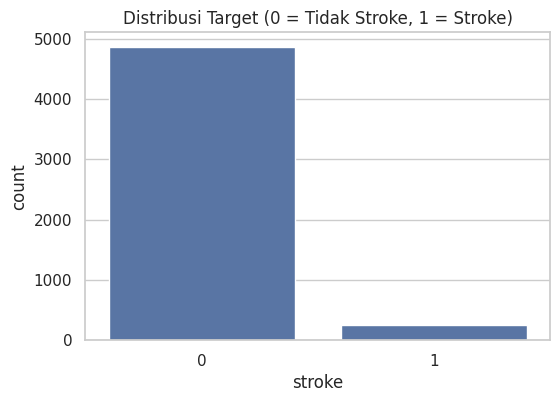

stroke
0    4861
1     249
Name: count, dtype: int64

Proporsi stroke '1': 4.87%


In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df)
plt.title('Distribusi Target (0 = Tidak Stroke, 1 = Stroke)')
plt.show()

print(df['stroke'].value_counts())
print(f"\nProporsi stroke '1': {df['stroke'].value_counts(normalize=True)[1]*100:.2f}%")

**Distribusi Fitur Numerik**

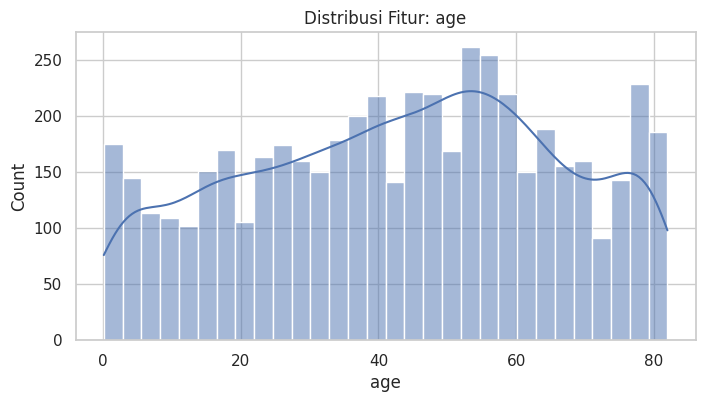

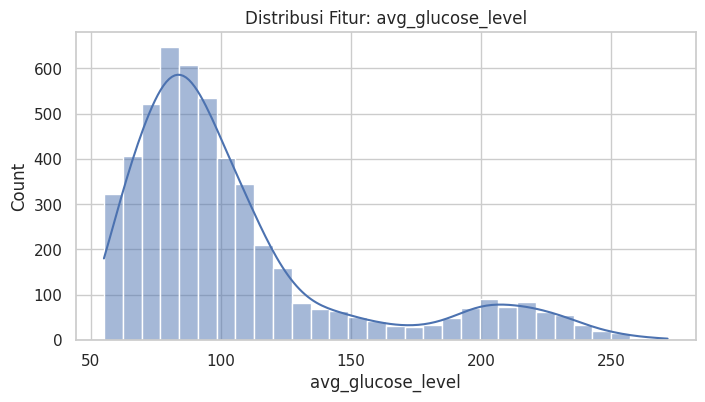

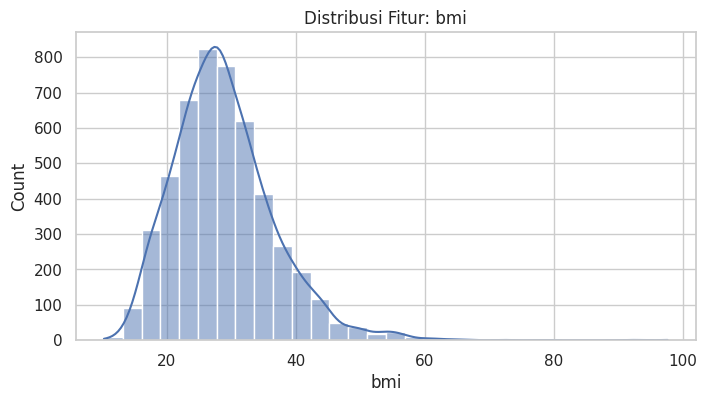

In [29]:
numerical_features = ['age', 'avg_glucose_level', 'bmi']

for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribusi Fitur: {col}')
    plt.show()

**Distribusi Fitur Kategorikal**

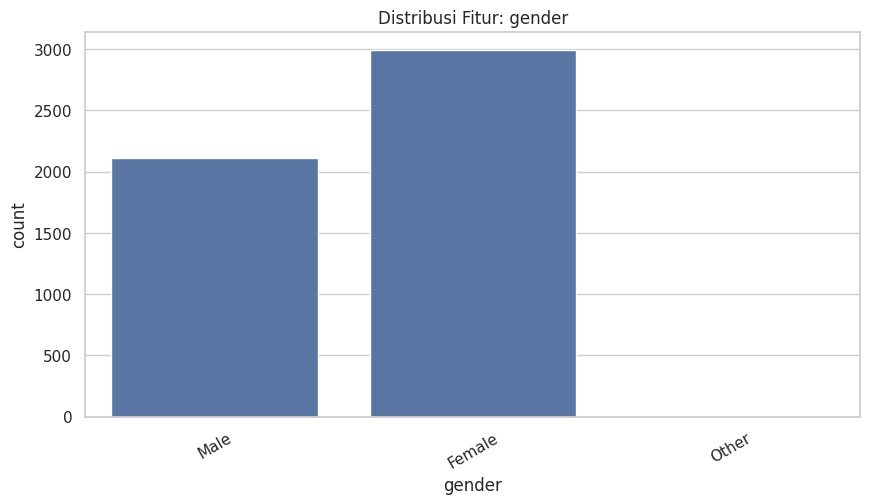

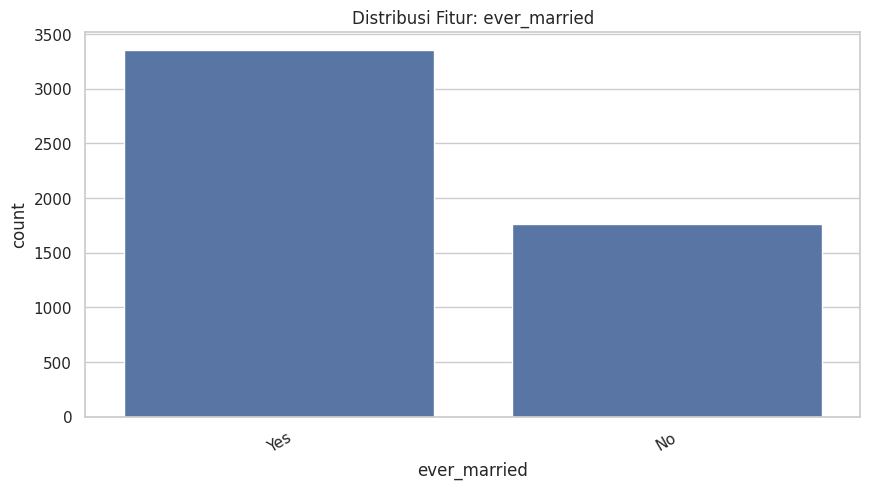

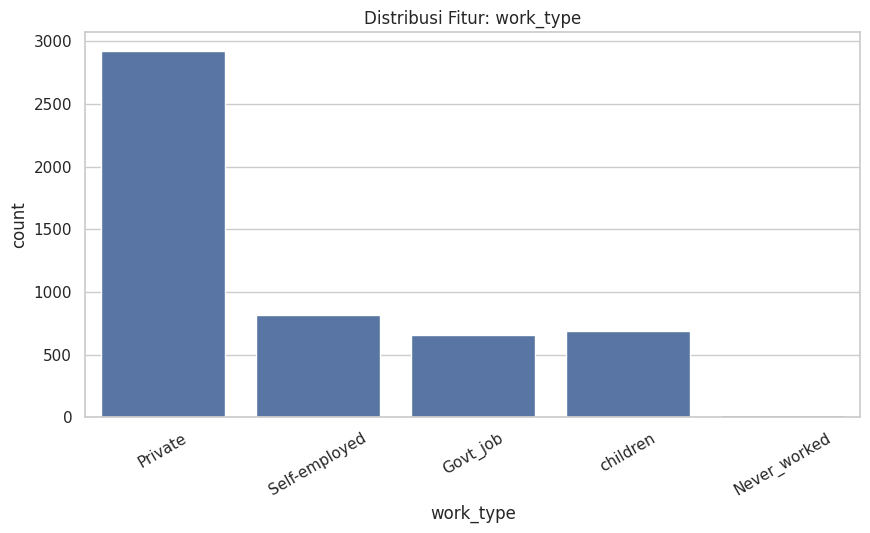

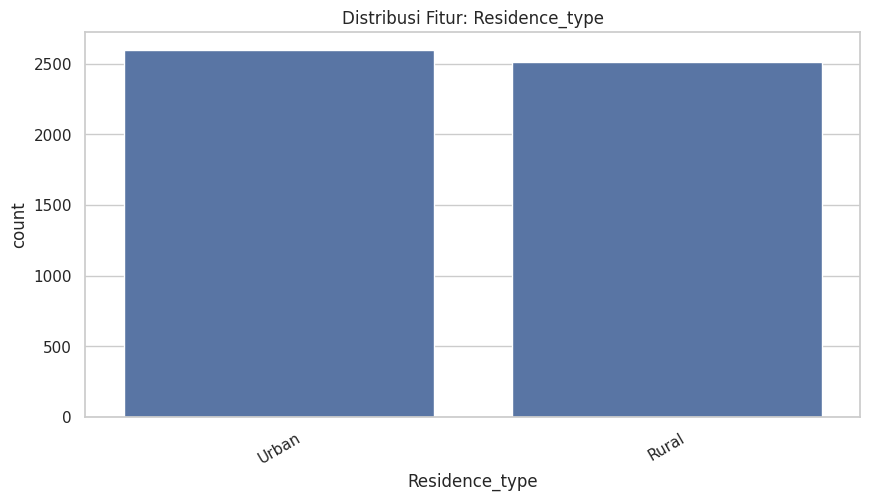

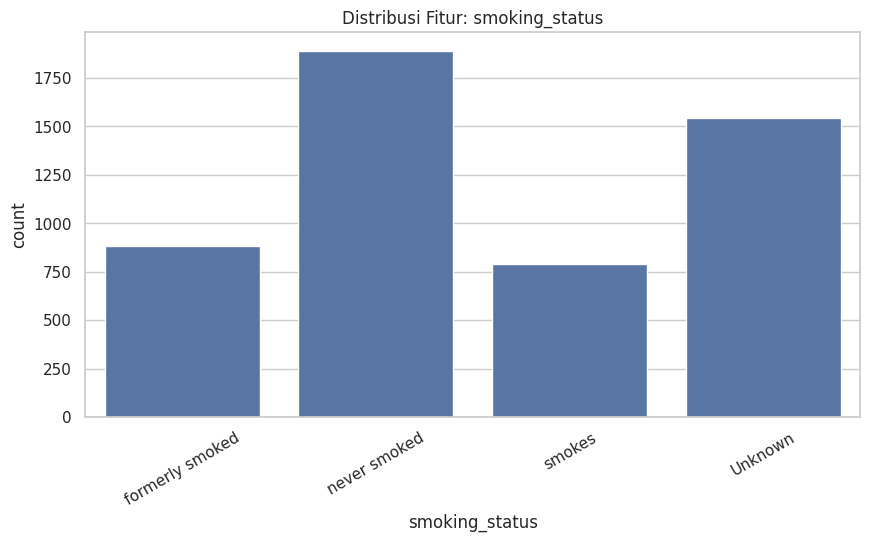

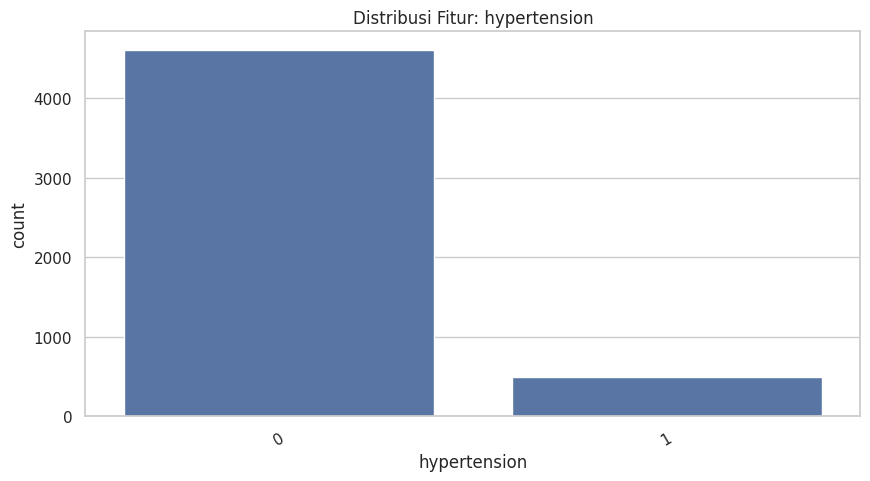

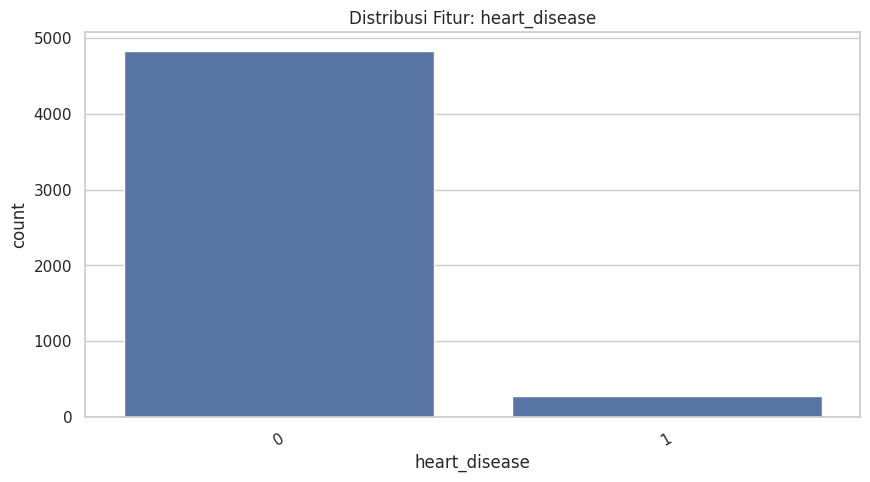

In [30]:
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribusi Fitur: {col}')
    plt.xticks(rotation=30)
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

**1. Drop kolom 'id'**

In [31]:
df_clean = df.drop('id', axis=1)

**2. Handle 'Other' di gender (hanya ada 1 data, jadi kita drop barisnya)**

In [32]:
df_clean = df_clean[df_clean['gender'] != 'Other']
print(f"Ukuran data setelah drop 'Other' di gender: {df_clean.shape}")

Ukuran data setelah drop 'Other' di gender: (5109, 11)


**Pemisahan Data**

In [33]:
X = df_clean.drop('stroke', axis=1)
y = df_clean['stroke']

# Split data, gunakan 'stratify=y' karena data kita imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Ukuran X_train: {X_train.shape}')
print(f'Ukuran X_test: {X_test.shape}')

Ukuran X_train: (4087, 10)
Ukuran X_test: (1022, 10)


**Pipeline Preprocessing**

In [35]:
# Pengemlopokan kolom numerik dan kategorikal
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Pipeline untuk fitur numerik
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline untuk fitur kategorikal
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# penggabungkan kedua pipeline menggunakan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)

print("Pipeline preprocessing berhasil dibuat:")
preprocessor

Pipeline preprocessing berhasil dibuat:


ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'avg_glucose_level', 'bmi']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'hypertension', 'heart_disease',
                                  'ever_married', 'work_type', 'Residence_type',
                                  'smoking_status'])])

**pipeline ke data dan Simpan**

In [36]:
# Pipeline (FIT dan TRANSFORM di data latih)
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Pipeline (HANYA TRANSFORM di data uji)
X_test_preprocessed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
df_train_preprocessed = pd.DataFrame(X_train_preprocessed, columns=feature_names, index=X_train.index)
df_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=feature_names, index=X_test.index)

# Gabungan fitur (X) dengan target (y)
df_train_final = pd.concat([df_train_preprocessed, y_train], axis=1)
df_test_final = pd.concat([df_test_preprocessed, y_test], axis=1)

df_train_final.head

<bound method NDFrame.head of       num__age  num__avg_glucose_level  num__bmi  cat__gender_Female  \
845   0.209397               -0.821221  0.549234                 1.0   
3745 -0.629845               -0.485884 -0.988900                 1.0   
4184 -0.364822                0.302317 -0.769166                 1.0   
3410 -0.232310                0.062342  0.497532                 0.0   
284  -1.292405               -0.527297  0.355351                 0.0   
...        ...                     ...       ...                 ...   
1434  0.076885               -0.291800  0.807744                 1.0   
461  -1.204064                0.169570 -1.208633                 1.0   
1052  0.783615               -0.609900  0.949924                 1.0   
1757 -0.541504               -0.712875 -0.368476                 0.0   
5053  0.121055               -1.120518 -0.135817                 1.0   

      cat__gender_Male  cat__hypertension_0  cat__hypertension_1  \
845                0.0                  1.0                  0.0   
3745               0.0                  1.0                  0.0   
4184               0.0                  1.0                  0.0   
3410               1.0                  1.0                  0.0   
284                1.0                  1.0                  0.0   
...                ...                  ...                  ...   
1434               0.0                  1.0                  0.0   
461                0.0                  1.0                  0.0   
1052               0.0                  1.0                  0.0   
1757               1.0                  1.0                  0.0   
5053               0.0                  1.0                  0.0   

      cat__heart_disease_0  cat__heart_disease_1  cat__ever_married_No  ...  \
845                    1.0                   0.0                   0.0  ...   
3745                   1.0                   0.0                   1.0  ...   
4184                   1.0                   0.0                   0.0  ...   
3410                   1.0                   0.0                   0.0  ...   
284                    1.0                   0.0                   1.0  ...   
...                    ...                   ...                   ...  ...   
1434                   1.0                   0.0                   0.0  ...   
461                    1.0                   0.0                   1.0  ...   
1052                   1.0                   0.0                   0.0  ...   
1757                   1.0                   0.0                   0.0  ...   
5053                   1.0                   0.0                   0.0  ...   

      cat__work_type_Private  cat__work_type_Self-employed  \
845                      1.0                           0.0   
3745                     1.0                           0.0   
4184                     1.0                           0.0   
3410                     1.0                           0.0   
284                      0.0                           0.0   
...                      ...                           ...   
1434                     1.0                           0.0   
461                      0.0                           0.0   
1052                     1.0                           0.0   
1757                     1.0                           0.0   
5053                     0.0                           0.0   

      cat__work_type_children  cat__Residence_type_Rural  \
845                       0.0                        0.0   
3745                      0.0                        0.0   
4184                      0.0                        1.0   
3410                      0.0                        1.0   
284                       0.0                        0.0   
...                       ...                        ...   
1434                      0.0                        0.0   
461                       1.0                        1.0   
1052                      0.0                        1

In [37]:
# Simpan ke file CSV baru
df_train_final.to_csv('train_preprocessed.csv', index=False)
df_test_final.to_csv('test_preprocessed.csv', index=False)

print("\nData latih dan data uji yang sudah bersih berhasil disimpan ke:")
print("1. train_preprocessed.csv")
print("2. test_preprocessed.csv")


Data latih dan data uji yang sudah bersih berhasil disimpan ke:
1. train_preprocessed.csv
2. test_preprocessed.csv
